In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/AI_SEM5/csv_file/Copy of devnagari digit/DevanagariHandwrittenDigitDataset"))

['Test', 'Train']


**Task 1: Data Preparation**

In [ ]:
import numpy as np
from PIL import Image
from keras.utils import to_categorical

In [9]:
def load_data(base_path, folder_name):
  X,y = [], []
  folder_path = os.path.join(base_path, folder_name)

  #loop through digits 10 to 9
  for label in range(10):
    #looks specifically for folders named digit_0...
    class_folder = os.path.join(folder_path, f"digit_{label}")

    if not os.path.exists(class_folder):
      continue

    for img_name in os.listdir(class_folder):
      img_path = os.path.join(class_folder, img_name)
      try:
        #open, convert to grayscale, resize to 28x28
        img = Image.open(img_path).convert('L').resize((28,28))
        #Normalize pixels to 0-1 range
        img_array = np.array(img) / 255.0
        X.append(img_array)
        y.append(label)
      except Exception as e:
        pass
  return np.array(X), np.array(y)

#path of unzipped folder
dataset_path = "/content/drive/MyDrive/AI_SEM5/csv_file/Copy of devnagari digit/DevanagariHandwrittenDigitDataset"

print("Loading training data...")
X_train, y_train = load_data(dataset_path, "Train")

print("Loading testing data...")
X_test, y_test = load_data(dataset_path, "Test")

#one hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")



Loading training data...
Loading testing data...
Training data shape: (17000, 28, 28)
Testing data shape: (3002, 28, 28)


**Task 2: Build the FCN Model**

In [10]:
from keras.models import Sequential   # Import Sequential model to build a linear stack of layers
from keras.layers import Dense, Flatten   # Import Dense (fully connected) and Flatten layers

model = Sequential()   # Initialize the Sequential model

model.add(Flatten(input_shape=(28,28)))
# Flatten layer converts 2D input (28x28 image) into 1D vector (784,) for dense layers

model.add(Dense(64, activation='sigmoid'))
# First hidden layer with 64 neurons using sigmoid activation function

model.add(Dense(128, activation='sigmoid'))
# Second hidden layer with 128 neurons using sigmoid activation

model.add(Dense(256, activation='sigmoid'))
# Third hidden layer with 256 neurons using sigmoid activation

model.add(Dense(10, activation='softmax'))
# Output layer with 10 neurons (for 10 classes) using softmax for probability distribution

model.summary()
# Display the model architecture (layers, parameters, output shapes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3: Model Compilation**

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Task 4: Train the Model**

In [12]:
from keras.callbacks import EarlyStopping, ModelCheckpoint   # Import callback functions

# define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4),  # Stop training if validation loss doesn't improve for 4 epochs
    ModelCheckpoint(filepath='best_devnagari_model.keras', save_best_only=True)  # Save only the best model
]

# Train the model
history = model.fit(
    X_train, y_train,        # Training data
    epochs=20,               # Total number of training epochs
    batch_size=128,          # Number of samples per batch
    validation_split=0.2,    # Use 20% data for validation
    callbacks=callbacks,     # Apply callbacks during training
    verbose=1                # Show training progress
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4707 - loss: 1.6379 - val_accuracy: 0.0000e+00 - val_loss: 7.1427
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8224 - loss: 0.5230 - val_accuracy: 0.0000e+00 - val_loss: 8.3943
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9018 - loss: 0.2997 - val_accuracy: 0.0000e+00 - val_loss: 8.9527
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9401 - loss: 0.2081 - val_accuracy: 0.0000e+00 - val_loss: 9.5588
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9546 - loss: 0.1572 - val_accuracy: 0.0000e+00 - val_loss: 9.8243


**Task 5: Evaluate the Model**

In [13]:
#evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7575 - loss: 2.1002

Final Test Accuracy: 0.7575
Final Test Loss: 2.1002


**Visualization**

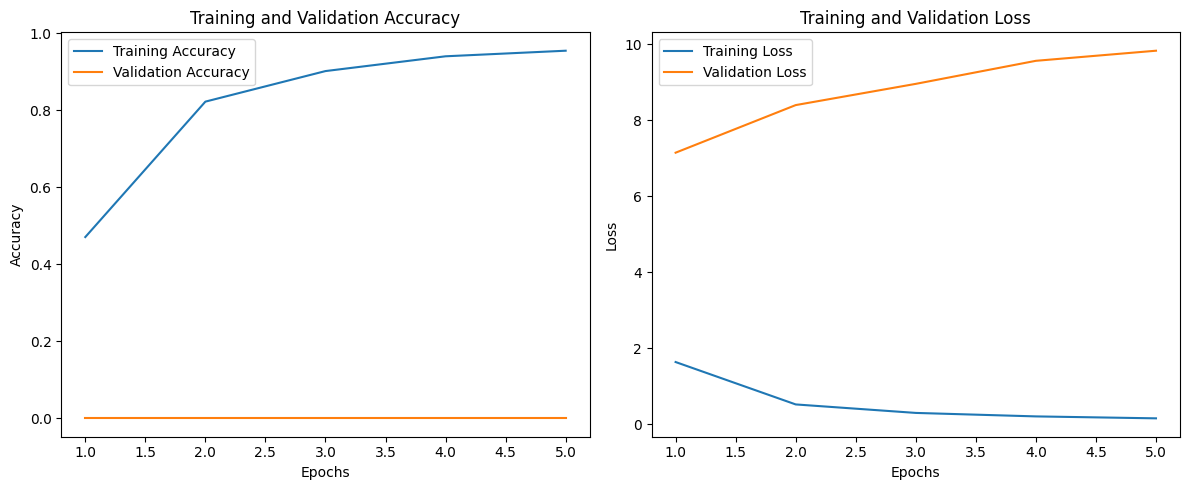

In [14]:
import matplotlib.pyplot as plt   # Import matplotlib for plotting graphs

# Extract data from the history object
acc = history.history['accuracy']        # Training accuracy values
val_acc = history.history['val_accuracy']  # Validation accuracy values
loss = history.history['loss']           # Training loss values
val_loss = history.history['val_loss']   # Validation loss values
epochs_range = range(1, len(acc) + 1)    # Create range for epochs

plt.figure(figsize=(12, 5))   # Set figure size

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)   # First subplot (1 row, 2 columns, position 1)
plt.plot(epochs_range, acc, label='Training Accuracy')   # Plot training accuracy
plt.plot(epochs_range, val_acc, label='Validation Accuracy')   # Plot validation accuracy
plt.title('Training and Validation Accuracy')   # Title of the plot
plt.xlabel('Epochs')   # X-axis label
plt.ylabel('Accuracy')   # Y-axis label
plt.legend()   # Show legend

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)   # Second subplot
plt.plot(epochs_range, loss, label='Training Loss')   # Plot training loss
plt.plot(epochs_range, val_loss, label='Validation Loss')   # Plot validation loss
plt.title('Training and Validation Loss')   # Title of the plot
plt.xlabel('Epochs')   # X-axis label
plt.ylabel('Loss')   # Y-axis label
plt.legend()   # Show legend

plt.tight_layout()   # Adjust layout to prevent overlap
plt.show()   # Display the plots

**Task 6: Save and Load the Model**

In [15]:
# Save the model to an HDF5 file
model.save('devnagari_digit_model.keras')
print("Model saved successfully as devnagari_digit_model.h5")

Model saved successfully as devnagari_digit_model.h5


In [16]:
loaded_model = tf.keras.models.load_model('devnagari_digit_model.keras')
load_loss, load_acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Loaded Model Test Accuracy: {load_acc:.4f}")

Loaded Model Test Accuracy: 0.7575


**Task 7: Predictions**

In [17]:
# Make predictions
predictions = model.predict(X_test[500:505])

# Convert probability distributions to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[500:505], axis=1)

print(f"Predicted Labels: {predicted_labels}")
print(f"Actual Labels:    {true_labels}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Labels: [1 1 1 1 1]
Actual Labels:    [1 1 1 1 1]
